In [29]:
import pandas as pd

df = pd.read_csv("../Processed_data/unified_data_new.csv")

print(df.shape)

(22672, 15)


In [30]:
# sanity: target distributions per source
print(df.groupby("source_dataset")[["runtime_s", "peak_mem", "energy_j"]].describe())

# how much data per architecture for the same-arch baseline?
print(df.groupby(["source_dataset", "node"]).size())

# the process feature — how many distinct task types?
print(df["process"].nunique(), "distinct processes")
print(df["process"].value_counts().head(10))

               runtime_s                                                      \
                   count           mean           std  min      25%      50%   
source_dataset                                                                 
augur_gu          1993.0  230485.904165  4.371731e+05  0.0  16000.0  85500.0   
augur_hu         11855.0  121240.052805  2.189949e+05  0.0   7500.0  36000.0   
lotaru            8824.0  309632.404238  1.065967e+06  8.0   8363.5  36069.5   

                                      peak_mem                ...  \
                      75%         max    count          mean  ...   
source_dataset                                                ...   
augur_gu        267000.00   5072000.0   1990.0  2.552580e+09  ...   
augur_hu        154000.00   8318207.0  11855.0  2.559022e+09  ...   
lotaru          191846.25  24154000.0   8824.0  1.680080e+09  ...   

                                           energy_j                \
                         75%       

In [31]:
df["task_type"] = df["process"].str.split(":").str[-1].str.upper()
print(df["task_type"].nunique(), "normalized task types")
print(df["task_type"].value_counts().head(20))

137 normalized task types
task_type
SAMTOOLS_FLAGSTAT          1296
FASTQC                     1240
SAMTOOLS_STATS             1152
SAMTOOLS_IDXSTATS          1099
SAMTOOLS_INDEX             1086
TRIMGALORE                  790
SAMTOOLS_SORT               717
BWA_MEM                     667
UCSC_BEDGRAPHTOBIGWIG       527
PHANTOMPEAKQUALTOOLS        504
BEDTOOLS_GENOMECOV          422
PICARD_MARKDUPLICATES       412
PRESEQ                      390
SORT_BAM                    389
QUALIMAP                    309
DEEPTOOLS_PLOTHEATMAP       294
DEEPTOOLS_PLOTPROFILE       288
BAM_REMOVE_ORPHANS          281
DEEPTOOLS_COMPUTEMATRIX     270
PRESEQ_LCEXTRAP             268
Name: count, dtype: int64


In [32]:
# Compare a known task type across sources
for src in ["augur_hu", "lotaru"]:
    sub = df[(df["source_dataset"]==src) & (df["task_type"]=="FASTQC")]
    print(src, "FASTQC runtime:", sub["runtime_s"].median())

augur_hu FASTQC runtime: 97000.0
lotaru FASTQC runtime: 20828.5


In [33]:
print("zero runtime:", (df["runtime_s"]==0).sum())
print("zero energy:", (df["energy_j"]==0).sum())

zero runtime: 1380
zero energy: 1


# Phase 2 - Same Architecture Baseline modelling

In [34]:
from sklearn.ensemble import  RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, median_absolute_error, mean_absolute_percentage_error 

In [35]:
hu = df[df["source_dataset"]== "augur_hu"] .copy()

hu

,source_dataset,node,source_workflow,process,runtime_s,peak_mem,energy_j,rchar,cpus,concurrent_task_count,cores,ram,cpu_benchmark,io_read,io_write,task_type
1993,augur_hu,hu-c42,atacseq,NFCORE_ATACSEQ:ATACSEQ:CUSTOM_DUMPSOFTWAREVERS...,113.0,7487488.0,NaN,1.026386e+06,1.0,0.0,32.0,256.0,1049.80,1380.0,972.0,CUSTOM_DUMPSOFTWAREVERSIONS
1994,augur_hu,hu-c44,atacseq,NFCORE_ATACSEQ:ATACSEQ:CUSTOM_DUMPSOFTWAREVERS...,131.0,4052992.0,NaN,1.026232e+06,1.0,0.0,32.0,256.0,1070.40,421.0,492.0,CUSTOM_DUMPSOFTWAREVERSIONS
1995,augur_hu,hu-c40,atacseq,NFCORE_ATACSEQ:ATACSEQ:FASTQ_ALIGN_BWA:BAM_SOR...,4000.0,7151616.0,510.68940,5.521684e+08,1.0,5.0,32.0,256.0,1056.95,1362.0,952.0,SAMTOOLS_FLAGSTAT
1996,augur_hu,hu-c42,atacseq,NFCORE_ATACSEQ:ATACSEQ:FASTQ_ALIGN_BWA:BAM_SOR...,4000.0,6787072.0,396.85230,5.521684e+08,1.0,3.0,32.0,256.0,1049.80,1380.0,972.0,SAMTOOLS_FLAGSTAT
1997,augur_hu,hu-c45,atacseq,NFCORE_ATACSEQ:ATACSEQ:FASTQ_ALIGN_BWA:BAM_SOR...,4000.0,7012352.0,540.37330,5.521682e+08,1.0,4.0,32.0,256.0,1066.66,420.0,499.0,SAMTOOLS_FLAGSTAT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13843,augur_hu,hu-c45,rnaseq,NFCORE_RNASEQ:RNASEQ:SUBREAD_FEATURECOUNTS,29000.0,363655168.0,4528.19370,3.229310e+09,6.0,4.0,32.0,256.0,1066.66,420.0,499.0,SUBREAD_FEATURECOUNTS
13844,augur_hu,hu-c44,rnaseq,NFCORE_RNASEQ:RNASEQ:SUBREAD_FEATURECOUNTS,28000.0,397799424.0,3851.28020,3.995100e+09,6.0,5.0,32.0,256.0,1070.40,421.0,492.0,SUBREAD_FEATURECOUNTS
13845,augur_hu,hu-c45,rnaseq,NFCORE_RNASEQ:RNASEQ:SUBREAD_FEATURECOUNTS,28000.0,402229248.0,3731.54060,3.996086e+09,6.0,7.5,32.0,256.0,1066.66,420.0,499.0,SUBREAD_FEATURECOUNTS
13846,augur_hu,hu-c40,rnaseq,NFCORE_RNASEQ:RNASEQ:SUBREAD_FEATURECOUNTS,22500.0,302825472.0,2996.37345,2.381857e+09,6.0,4.5,32.0,256.0,1056.95,1362.0,952.0,SUBREAD_FEATURECOUNTS


In [36]:
hu["task_type"] = hu["process"].str.split(":").str[-1].str.upper()
hu_encoded = pd.get_dummies(hu,columns=["task_type"], prefix="task")

base_features = ["rchar","cpus","concurrent_task_count"]
task_features = [c for c in hu_encoded.columns if c.startswith("task_)")]
feature_cols = base_features + task_features

In [37]:
def evaluate_target(data,target):
    d  = data.dropna(subset= [target] + base_features)
    d = d[d[target] >0]
    X = d[feature_cols]
    y = d[target]
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    model = RandomForestRegressor(n_estimators=200,random_state=42, n_jobs=-1)
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    print(f"{target:12s} R2={r2_score(y_test,pred):.3f} "
          f"MAPE = {mean_absolute_percentage_error(y_test,pred):.2f} "
          f"MedAE = {median_absolute_error(y_test,pred): ,.0f} (n={len(d)})"
          )
    return model

print("Same architecture baseline - augur_hu\n")
models= {t:evaluate_target(hu_encoded,t) for t in ["runtime_s","peak_mem","energy_j"]}

Same architecture baseline - augur_hu



runtime_s    R2=0.892 MAPE = 0.62 MedAE =  10,353 (n=10606)
peak_mem     R2=0.683 MAPE = 14.47 MedAE =  32,074,342 (n=11855)
energy_j     R2=0.853 MAPE = 0.58 MedAE =  1,759 (n=10817)


In [38]:
m = models["energy_j"]
importances = sorted(zip(feature_cols, m.feature_importances_), key=lambda x: -x[1])[:8]
for name, imp in importances:
    print(f"{name:35s} {imp:.3f}")

rchar                               0.816
concurrent_task_count               0.139
cpus                                0.045


# Phase 4 -

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_percentage_error

df["task_type"]= df["process"].str.split(":").str[-1].str.upper()
base_features =  ["rchar","cpus","cores","ram", "cpu_benchmark", "io_read", "io_write"]



def cross_architecture_exp(df, train_source,test_source,target):
    d = df.dropna(subset=[target] + base_features).copy()
    d = d[d[target] > 0]
    d = pd.get_dummies(d, columns=["task_type"], prefix="task")
    task_cols = [c for c in d.columns if c.startswith("task_")]
    feats = base_features + task_cols
    train = d[d["source_dataset"].isin(train_source)]
    test  = d[d["source_dataset"] == test_source]
    Xtr, ytr = train[feats], train[target]
    Xte, yte = test.reindex(columns=feats, fill_value=0), test[target]
    model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    print(f"  {target:10s}  R2={r2_score(yte, pred):.3f}  MAPE={mean_absolute_percentage_error(yte, pred):.2f}")

print("Train augur_gu -> test augur_hu:")
for t in ["runtime_s", "peak_mem", "energy_j"]:
    cross_architecture_exp(df, ["augur_gu"], "augur_hu", t)

print("\nTrain augur_hu -> test augur_gu:")
for t in ["runtime_s", "peak_mem", "energy_j"]:
    cross_architecture_exp(df, ["augur_hu"], "augur_gu", t) 

Train augur_gu -> test augur_hu:
  runtime_s   R2=-0.069  MAPE=2.42
  peak_mem    R2=0.950  MAPE=1.09
  energy_j    R2=0.694  MAPE=0.44

Train augur_hu -> test augur_gu:
  runtime_s   R2=0.603  MAPE=0.50
  peak_mem    R2=0.972  MAPE=0.33
  energy_j    R2=0.789  MAPE=0.38


In [40]:
for src in ["augur_gu", "augur_hu"]:
    r = df[(df["source_dataset"]==src)]["runtime_s"]
    print(f"{src}: median={r.median():.0f}, max={r.max():.0f}, 95th={r.quantile(0.95):.0f}")

augur_gu: median=85500, max=5072000, 95th=870400
augur_hu: median=36000, max=8318207, 95th=526450


In [45]:

def few_shot_collect(df, train_source, target_source, target, fractions=[0.0, 0.05, 0.10, 0.20, 0.50]):
    d = df.dropna(subset=[target] + base_features).copy()
    d = d[d[target] > 0]
    d = pd.get_dummies(d, columns=["task_type"], prefix="task")
    task_cols = [c for c in d.columns if c.startswith("task_")]
    feats = base_features + task_cols
    src = d[d["source_dataset"] == train_source]
    tgt = d[d["source_dataset"] == target_source].sample(frac=1.0, random_state=42)

    rows = []
    for frac in fractions:
        n_cal = int(len(tgt) * frac)
        train = pd.concat([src, tgt.iloc[:n_cal]], ignore_index=True)
        test = tgt.iloc[n_cal:]
        model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
        model.fit(train[feats], train[target])
        pred = model.predict(test.reindex(columns=feats, fill_value=0))
        rows.append({
            "train": train_source,
            "test": target_source,
            "target": target,
            "target_fraction": frac,
            "r2": r2_score(test[target], pred),
            "n_train": len(train),
            "n_test": len(test),
        })
    return rows

# Collect all combinations
all_results = []
for (train_s, test_s) in [("augur_gu", "augur_hu"), ("augur_hu", "augur_gu")]:
    for target in ["runtime_s", "peak_mem", "energy_j"]:
        all_results.extend(few_shot_collect(df, train_s, test_s, target))

results_df = pd.DataFrame(all_results)
results_df.to_csv("../Processed_data/cross_arch_fewshot_results.csv", index=False)
print("Saved", len(results_df), "rows")
print(results_df)

Saved 30 rows
       train      test     target  target_fraction        r2  n_train  n_test
0   augur_gu  augur_hu  runtime_s             0.00 -0.068695     1862   10606
1   augur_gu  augur_hu  runtime_s             0.05  0.768704     2392   10076
2   augur_gu  augur_hu  runtime_s             0.10  0.775184     2922    9546
3   augur_gu  augur_hu  runtime_s             0.20  0.786140     3983    8485
4   augur_gu  augur_hu  runtime_s             0.50  0.704287     7165    5303
5   augur_gu  augur_hu   peak_mem             0.00  0.950080     1988   11855
6   augur_gu  augur_hu   peak_mem             0.05  0.988795     2580   11263
7   augur_gu  augur_hu   peak_mem             0.10  0.991325     3173   10670
8   augur_gu  augur_hu   peak_mem             0.20  0.991585     4359    9484
9   augur_gu  augur_hu   peak_mem             0.50  0.995147     7915    5928
10  augur_gu  augur_hu   energy_j             0.00  0.694167     1903   10817
11  augur_gu  augur_hu   energy_j             0.05

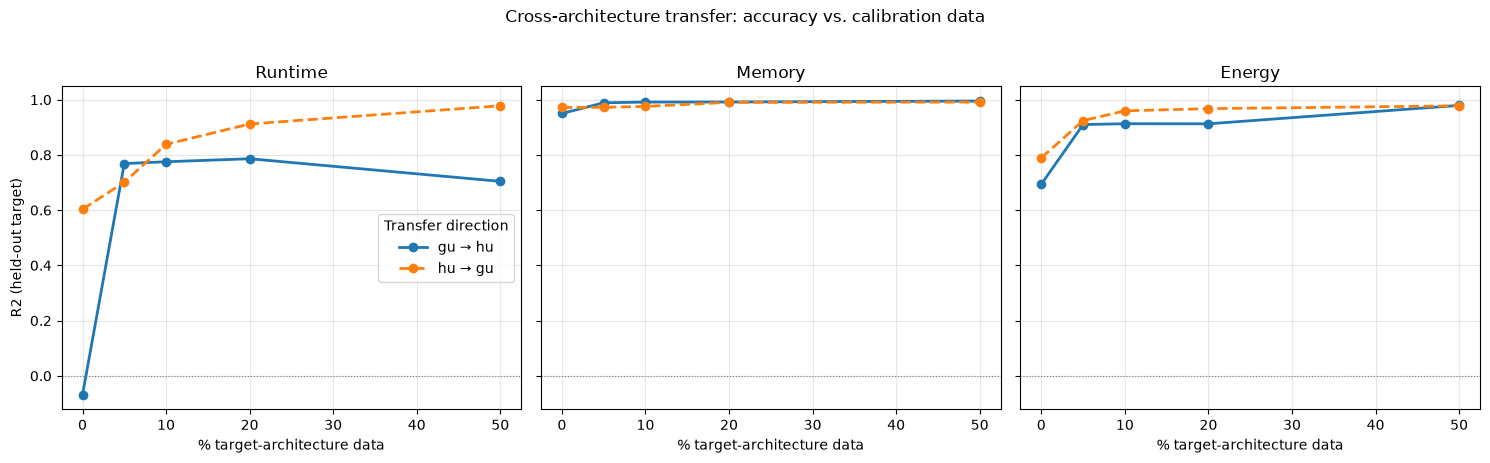

In [60]:
import matplotlib.pyplot as plt

metrics = results_df["target"].unique().tolist()
title_list = ["Runtime","Memory","Energy"]
titles= dict(zip(metrics,title_list))
directions = [("augur_gu", "augur_hu"), ("augur_hu", "augur_gu")]
dir_style = {("augur_gu", "augur_hu"): ("-", "gu → hu"),
             ("augur_hu", "augur_gu"): ("--", "hu → gu")}

fig,axes = plt.subplots(1,3,figsize=(15,4.5),sharey=True)

for ax, metric in zip(axes,metrics):
    for(train_s,test_s) in directions:
        sub = results_df[
            (results_df["target"] == metric) &
            (results_df["train"] == train_s) &
            (results_df["test"] == test_s)
        ].sort_values("target_fraction")

        style,label = dir_style[(train_s,test_s)]
        ax.plot(sub["target_fraction"] * 100, sub["r2"],
                style,marker="o",label= label, linewidth= 2)
        
    
    ax.axhline(0,color="grey",linewidth=0.8,linestyle=":")
    ax.set_title(titles[metric])
    ax.set_xlabel("% target-architecture data")
    ax.grid(True,alpha=0.3)


axes[0].set_ylabel("R2 (held-out target)")
axes[0].legend(title="Transfer direction")
fig.suptitle("Cross-architecture transfer: accuracy vs. calibration data", y=1.02)
plt.tight_layout()
plt.savefig("../Processed_data/data_cost_curve.png")
plt.show()

In [72]:
def get_architecture(row):
    if row["source_dataset"] == "lotaru":
        return f"lot_{row['node']}"
    elif row["source_dataset"] == "augur_gu":
        return "gu"
    else:
        return "hu"
    
df["architecture"] = df.apply(get_architecture,axis=1)
print(df["architecture"].value_counts())

architecture
hu           11855
gu            1993
lot_a1        1501
lot_a2        1501
lot_c2        1501
lot_n2        1501
lot_n1        1487
lot_local     1333
Name: count, dtype: int64


In [73]:

base_features = ["rchar", "cpus", "cores", "ram", "cpu_benchmark", "io_read", "io_write"]

def transfer_matrix(df, target, architectures):
    d = df.dropna(subset=[target] + base_features).copy()
    d = d[d[target] > 0]
    d = pd.get_dummies(d, columns=["task_type"], prefix="task")
    task_cols = [c for c in d.columns if c.startswith("task_")]
    feats = base_features + task_cols

    rows = []
    for train_arch in architectures:
        tr = d[d["architecture"] == train_arch]
        if len(tr) < 30:
            continue
        model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
        model.fit(tr[feats], tr[target])
        for test_arch in architectures:
            te = d[d["architecture"] == test_arch]
            if len(te) < 30:
                continue
            pred = model.predict(te.reindex(columns=feats, fill_value=0))
            rows.append({"train": train_arch, "test": test_arch,
                         "r2": r2_score(te[target], pred)})
    return pd.DataFrame(rows)

# Runtime — all architectures
architectures = df["architecture"].unique().tolist()
rt_matrix = transfer_matrix(df, "runtime_s", architectures)
rt_pivot = rt_matrix.pivot(index="train", columns="test", values="r2")
print("Runtime transfer matrix:")
print(rt_pivot.round(2))

Runtime transfer matrix:
test         gu     hu  lot_a1  lot_a2  lot_c2  lot_local  lot_n1  lot_n2
train                                                                    
gu         0.99  -0.07    0.07    0.07    0.19       0.19    0.12    0.18
hu         0.60   0.99    0.07    0.07    0.20       0.18    0.13    0.18
lot_a1    -1.65 -76.30    0.99    0.99   -0.18       0.53    0.71    0.20
lot_a2    -1.45 -74.08    0.98    0.99   -0.12       0.56    0.73    0.24
lot_c2    -0.23 -31.92    0.62    0.62    0.98       0.88    0.85    0.96
lot_local -0.32  -3.37    0.67    0.67    0.78       0.99    0.73    0.80
lot_n1    -0.32 -84.95    0.77    0.78    0.85       0.96    0.99    0.93
lot_n2    -0.29 -36.90    0.67    0.67    0.98       0.92    0.89    0.98


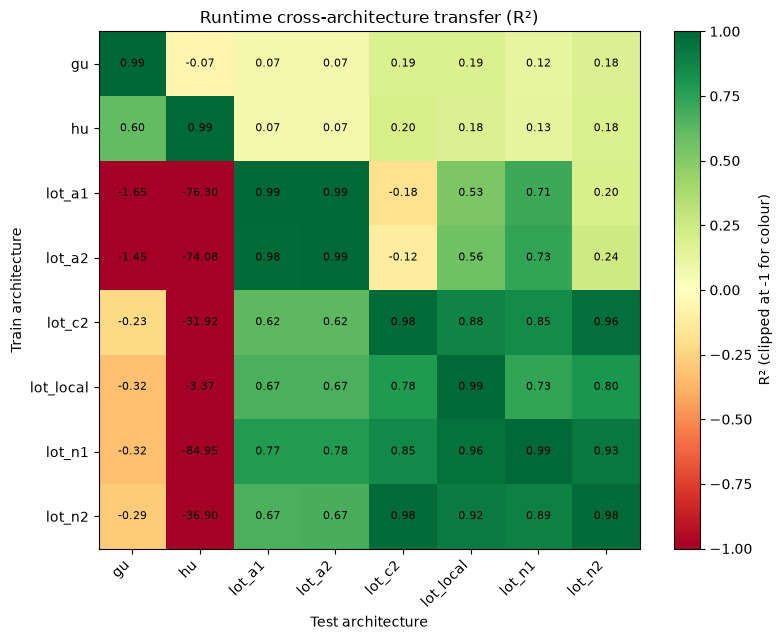

In [75]:
rt_clipped = rt_pivot.clip(lower=-1)
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(rt_clipped.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")

# Ticks
ax.set_xticks(range(len(rt_clipped.columns)))
ax.set_yticks(range(len(rt_clipped.index)))
ax.set_xticklabels(rt_clipped.columns, rotation=45, ha="right")
ax.set_yticklabels(rt_clipped.index)
ax.set_xlabel("Test architecture")
ax.set_ylabel("Train architecture")
ax.set_title("Runtime cross-architecture transfer (R²)")

# Annotate each cell with the TRUE (unclipped) value
for i in range(len(rt_pivot.index)):
    for j in range(len(rt_pivot.columns)):
        val = rt_pivot.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="black", fontsize=8)

fig.colorbar(im, ax=ax, label="R² (clipped at -1 for colour)")
plt.tight_layout()
plt.savefig("../Processed_data/runtime_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [76]:
mem_matrix = transfer_matrix(df, "peak_mem", architectures)
mem_pivot = mem_matrix.pivot(index="train", columns="test", values="r2")
print(mem_pivot.round(2))

test         gu    hu  lot_a1  lot_a2  lot_c2  lot_local  lot_n1  lot_n2
train                                                                   
gu         1.00  0.95    0.06    0.06    0.06       0.07    0.07    0.05
hu         0.97  1.00    0.04    0.04    0.04       0.05    0.04    0.03
lot_a1     0.00  0.04    1.00    0.99    0.99       0.98    0.99    0.98
lot_a2    -0.00  0.03    0.99    1.00    0.99       0.98    0.99    0.98
lot_c2    -0.00  0.03    0.99    0.99    1.00       0.98    0.99    0.99
lot_local  0.01  0.05    0.98    0.98    0.98       1.00    0.98    0.99
lot_n1    -0.00  0.03    0.99    0.99    0.99       0.99    1.00    0.99
lot_n2    -0.00  0.04    0.98    0.98    0.99       1.00    0.99    1.00


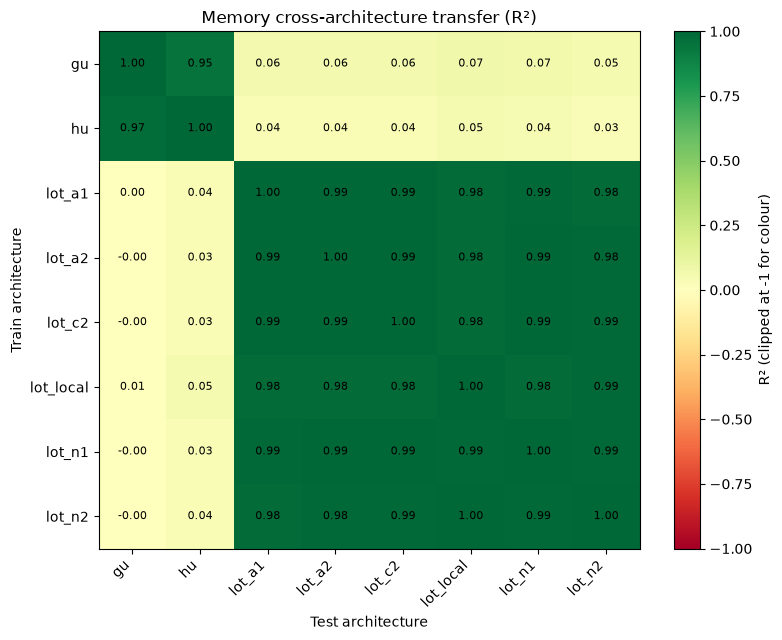

In [78]:
mem_clipped = mem_pivot.clip(lower=-1)
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(mem_clipped.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")

# Ticks
ax.set_xticks(range(len(mem_clipped.columns)))
ax.set_yticks(range(len(mem_clipped.index)))
ax.set_xticklabels(mem_clipped.columns, rotation=45, ha="right")
ax.set_yticklabels(mem_clipped.index)
ax.set_xlabel("Test architecture")
ax.set_ylabel("Train architecture")
ax.set_title("Memory cross-architecture transfer (R²)")

# Annotate each cell with the TRUE (unclipped) value
for i in range(len(mem_pivot.index)):
    for j in range(len(mem_pivot.columns)):
        val = mem_pivot.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="black", fontsize=8)

fig.colorbar(im, ax=ax, label="R² (clipped at -1 for colour)")
plt.tight_layout()
plt.savefig("../Processed_data/peak_mem_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [80]:
for src in ["augur_hu", "lotaru"]:
    sub = df[(df["source_dataset"]==src) & (df["peak_mem"]>0)]
    print(src, "rchar-memory corr:", round(sub["rchar"].corr(sub["peak_mem"]), 3),
          "| median mem:", f"{sub['peak_mem'].median():.2e}",
          "| median rchar:", f"{sub['rchar'].median():.2e}")

augur_hu rchar-memory corr: 0.148 | median mem: 3.61e+07 | median rchar: 1.25e+09
lotaru rchar-memory corr: 0.123 | median mem: 5.69e+08 | median rchar: 9.05e+08
